Script Overview
1. Create directories per year for the files
2. Iterates over files for each year directory and tokenizes them and counts for number of uncertainty terms
3. Combines all the years into one dataframe and creates a new column with mean uncertainty term per doc
4. Plots frequency of top 5 terms for each year
5. Plots the relationship between mean and year with two Linear models

1. Create directories per year for the files

In [ ]:
import os
from datetime import datetime
import shutil

def filter_articles_2024(directory, output_directory):
    filtered_articles = []

    for file in os.listdir(directory):
        if file.endswith("txt"):
            article_path = os.path.join(directory, file)

            with open(article_path, "r") as f:
                text = f.readlines()

                date = text[1].strip().replace("Date: ", "")

                try:
                    a_date = datetime.strptime(date, "%Y-%m-%d %H:%M:%S %Z")
                    # change date based on which year you want
                    if a_date >= datetime(2024,1,1):
                        filtered_articles.append(article_path)
                        output_path = os.path.join(output_directory, file)
                        shutil.copy(article_path, output_path)

                except ValueError:
                    print(f"Skipping {file} due to incorrect data format")

    return(filtered_articles)

In [ ]:
# change the name of the function for which year you want
filter_articles_2024("scraped_articles","2024_a")

2. Iterates over files for each year directory and tokenizes them and counts for number of uncertainty terms

In [15]:
import spacy
nlp = spacy.load("nl_core_news_sm")


uncertainty_terms = set([
    "altijd", "kans", "meestal", "misschien", "mogelijk", "nooit", "onmogelijk", "onwaarschijnlijk", "onzeker", 
    "soms", "twijfelachtig", "vaak", "vermoedelijk","waarschijnlijk", "zeker", "zelden", "bijna"
])

def tokenize(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()[4:]
        text = "".join(lines)
    doc = nlp(text)
    return doc

def find_uncertainty_terms(doc_tokens):
    found_terms = []
    found_terms += [w.text.lower() for w in doc_tokens if w.text.lower() in uncertainty_terms]
    return found_terms

2018

In [17]:
import os 
import pandas as pd

doc_u_counts = []
filenames = []
total_u_counts = 0
for file in os.listdir("2018_a"):
    file_path = os.path.join("2018_a", file)
    doc = tokenize(file_path)
    terms = find_uncertainty_terms(doc)
    if terms:
        doc_u_counts.append(len(terms))
        filenames.append(file)


df_2018 =pd.DataFrame(doc_u_counts , index = filenames , columns = ["Uncertainty Counts"]) 

2019

In [16]:
import os 

doc_u_counts = []
filenames = []
total_u_counts = 0
for file in os.listdir("2019_a"):
    file_path = os.path.join("2019_a", file)
    doc = tokenize(file_path)
    terms = find_uncertainty_terms(doc)
    if terms:
        doc_u_counts.append(len(terms))
        filenames.append(file)

df_2019 =pd.DataFrame(doc_u_counts , index = filenames , columns = ["Uncertainty Counts"])  

2020

In [4]:
import os 

doc_u_counts = []
filenames = []
total_u_counts = 0
for file in os.listdir("2020_a"):
    file_path = os.path.join("2020_a", file)
    doc = tokenize(file_path)
    terms = find_uncertainty_terms(doc)
    if terms:
        total_u_counts += 1
        doc_u_counts.append(len(terms))
        filenames.append(file)

df_2020 =pd.DataFrame(doc_u_counts , index = filenames , columns = ["Uncertainty Counts"])  

2021

In [5]:
import os 

doc_u_counts = []
filenames = []
total_u_counts = 0
for file in os.listdir("2021_a"):
    file_path = os.path.join("2021_a", file)
    doc = tokenize(file_path)
    terms = find_uncertainty_terms(doc)
    if terms:
        total_u_counts += 1
        doc_u_counts.append(len(terms))
        filenames.append(file)

df_2021 =pd.DataFrame(doc_u_counts , index = filenames , columns = ["Uncertainty Counts"])  

2022

In [6]:
import os 

doc_u_counts = []
filenames = []
total_u_counts = 0
for file in os.listdir("2022_a"):
    file_path = os.path.join("2022_a", file)
    doc = tokenize(file_path)
    terms = find_uncertainty_terms(doc)
    if terms:
        total_u_counts += 1
        doc_u_counts.append(len(terms))
        filenames.append(file)

df_2022 =pd.DataFrame(doc_u_counts , index = filenames , columns = ["Uncertainty Counts"])  

2023

In [7]:
import os 

doc_u_counts = []
filenames = []
total_u_counts = 0
for file in os.listdir("2023_a"):
    file_path = os.path.join("2023_a", file)
    doc = tokenize(file_path)
    terms = find_uncertainty_terms(doc)
    if terms:
        total_u_counts += 1
        doc_u_counts.append(len(terms))
        filenames.append(file)

df_2023 =pd.DataFrame(doc_u_counts , index = filenames , columns = ["Uncertainty Counts"])  

2024

In [8]:
import os 

doc_u_counts = []
filenames = []
total_u_counts = 0
for file in os.listdir("2024_a"):
    file_path = os.path.join("2024_a", file)
    doc = tokenize(file_path)
    terms = find_uncertainty_terms(doc)
    if terms:
        total_u_counts += 1
        doc_u_counts.append(len(terms))
        filenames.append(file)

df_2024 =pd.DataFrame(doc_u_counts , index = filenames , columns = ["Uncertainty Counts"])  

3. Combines all the years into one dataframe and creates a new column with mean uncertainty term per doc

In [9]:
d = {"year" : [2018,2019,2020,2021,2022,2023,2024], "no of docs":[df_2018.shape[0],df_2019.shape[0], df_2020.shape[0], df_2021.shape[0], df_2022.shape[0], df_2023.shape[0], df_2024.shape[0]], "uncertainty count":[df_2018["Uncertainty Counts"].sum(), df_2019["Uncertainty Counts"].sum(), df_2020["Uncertainty Counts"].sum(), df_2021["Uncertainty Counts"].sum(), df_2022["Uncertainty Counts"].sum(), df_2023["Uncertainty Counts"].sum(), df_2024["Uncertainty Counts"].sum()]}
df = pd.DataFrame(data = d)
import pandas as pd
df["year"] = pd.to_numeric(df["year"])
df["uncertainty count"] = pd.to_numeric(df["uncertainty count"])
df["Relative_Freq"] = df["uncertainty count"]/df["no of docs"]
df

,year,no of docs,uncertainty count,Relative_Freq
0,2018,442,1378,3.117647
1,2019,389,1320,3.393316
2,2020,449,1297,2.888641
3,2021,415,1281,3.086747
4,2022,404,1179,2.918317
5,2023,335,975,2.910448
6,2024,308,947,3.074675


4. Plots frequency of top 5 terms for each year

2018

In [ ]:
import os
from collections import Counter 
import pandas as pd
uncertainty_terms = set([
    "altijd", "kans", "meestal", "misschien", "mogelijk", "nooit", "onmogelijk", "onwaarschijnlijk", "onzeker", 
    "soms", "twijfelachtig", "vaak", "vermoedelijk","waarschijnlijk", "zeker", "zelden", "bijna"
])

def find_uncertainty_terms(doc_tokens):
    found_terms = []
    found_terms += [w.text.lower() for w in doc_tokens if w.text.lower() in uncertainty_terms]
    return found_terms

doc_u_counts = Counter()
filenames = []
total_u_counts = 0
for file in os.listdir("2018_a"):
    file_path = os.path.join("2018_a", file)
    doc = tokenize(file_path)
    terms = find_uncertainty_terms(doc)
    if terms:
        total_u_counts += 1
        doc_u_counts.update(terms)
        filenames.append(file)

y = list(doc_u_counts.values())
x = list(doc_u_counts.keys())
df18 = pd.DataFrame(dict(words = doc_u_counts.keys(), freq = doc_u_counts.values()))

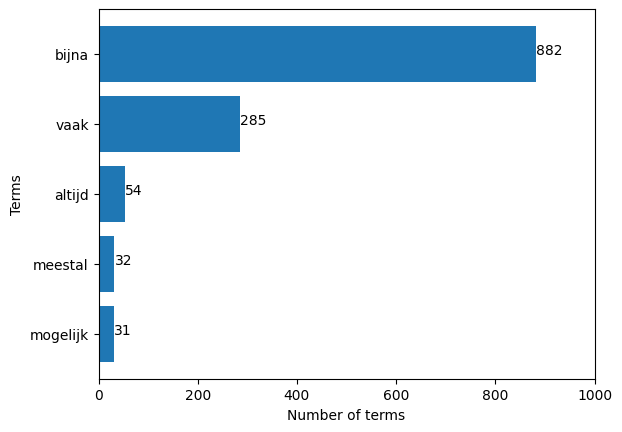

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
df_sorted = df18.sort_values(by = "freq", ascending=True)
y = list(doc_u_counts.values())
x = list(doc_u_counts.keys())
df18 = pd.DataFrame(dict(words = doc_u_counts.keys(), freq = doc_u_counts.values()))
df_sorted5 = df_sorted.tail(5)
def addlabels(df_sorted5):
    for i in range(len(df_sorted5)):
        plt.text(df_sorted5.iloc[i]["freq"] + 0.1,i, str(df_sorted5.iloc[i]["freq"]), fontsize = 10)
plt.barh(df_sorted5["words"] ,df_sorted5["freq"])
addlabels(df_sorted5)
plt.xlabel("Number of terms")
plt.ylabel("Terms")
plt.yticks(fontsize = 10)
plt.xlim(0,1000)
plt.show()

2019

In [24]:

doc_u_counts = Counter()
filenames = []
total_u_counts = 0
for file in os.listdir("2019_a"):
    file_path = os.path.join("2019_a", file)
    doc = tokenize(file_path)
    terms = find_uncertainty_terms(doc)
    if terms:
        total_u_counts += 1
        doc_u_counts.update(terms)
        filenames.append(file)


y = list(doc_u_counts.values())
x = list(doc_u_counts.keys())
df19 = pd.DataFrame(dict(words = doc_u_counts.keys(), freq = doc_u_counts.values()))


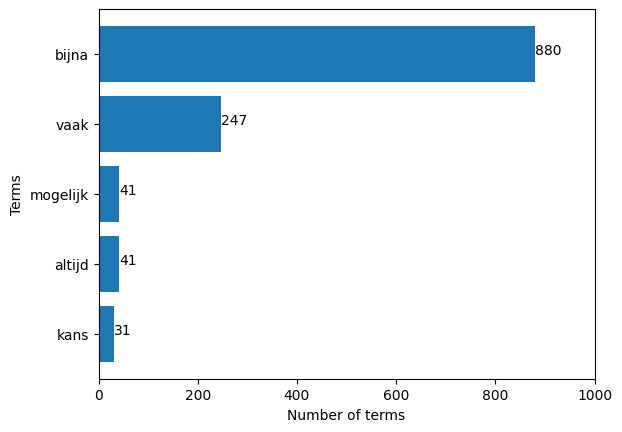

In [25]:
df_sorted = df19.sort_values(by = "freq", ascending=True)
df_sorted5 = df_sorted.tail(5)
def addlabels(df_sorted5):
    for i in range(len(df_sorted5)):
        plt.text(df_sorted5.iloc[i]["freq"] + 0.1,i, str(df_sorted5.iloc[i]["freq"]), fontsize = 10)
plt.barh(df_sorted5["words"] ,df_sorted5["freq"])
addlabels(df_sorted5)
plt.xlabel("Number of terms")
plt.ylabel("Terms")
plt.yticks(fontsize = 10)
plt.xlim(0,1000)
plt.show()

2020

In [15]:

doc_u_counts = Counter()
filenames = []
total_u_counts = 0
for file in os.listdir("2020_a"):
    file_path = os.path.join("2020_a", file)
    doc = tokenize(file_path)
    terms = find_uncertainty_terms(doc)
    if terms:
        total_u_counts += 1
        doc_u_counts.update(terms)
        filenames.append(file)


y = list(doc_u_counts.values())
x = list(doc_u_counts.keys())
df20 = pd.DataFrame(dict(words = doc_u_counts.keys(), freq = doc_u_counts.values()))


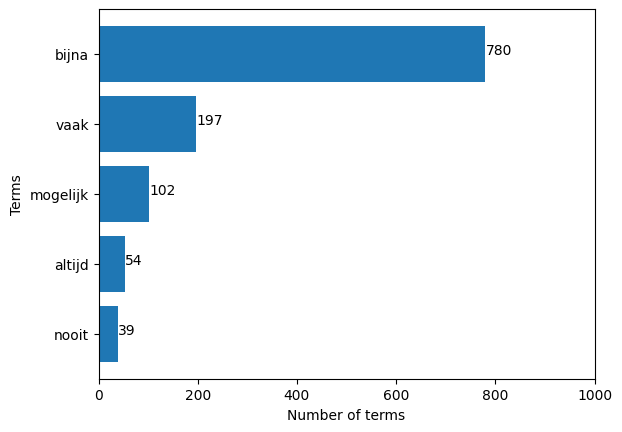

In [16]:
df_sorted = df20.sort_values("freq", ascending= False)


df_sorted = df_sorted.sort_values(by = "freq", ascending=True)
df_sorted5 = df_sorted.tail(5)
def addlabels(df_sorted5):
    for i in range(len(df_sorted5)):
        plt.text(df_sorted5.iloc[i]["freq"] + 0.1,i, str(df_sorted5.iloc[i]["freq"]), fontsize = 10)
plt.barh(df_sorted5["words"] ,df_sorted5["freq"])
addlabels(df_sorted5)
plt.xlabel("Number of terms")
plt.ylabel("Terms")
plt.yticks(fontsize = 10)
plt.xlim(0,1000)
plt.show()

2021

In [17]:

doc_u_counts = Counter()
filenames = []
total_u_counts = 0
for file in os.listdir("2021_a"):
    file_path = os.path.join("2021_a", file)
    doc = tokenize(file_path)
    terms = find_uncertainty_terms(doc)
    if terms:
        total_u_counts += 1
        doc_u_counts.update(terms)
        filenames.append(file)


y = list(doc_u_counts.values())
x = list(doc_u_counts.keys())
df21 = pd.DataFrame(dict(words = doc_u_counts.keys(), freq = doc_u_counts.values()))


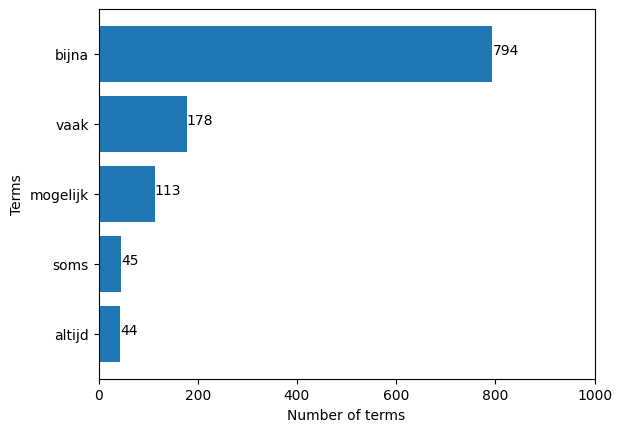

In [18]:
df_sorted = df21.sort_values("freq", ascending= False)



df_sorted = df_sorted.sort_values(by = "freq", ascending=True)
df_sorted5 = df_sorted.tail(5)
def addlabels(df_sorted5):
    for i in range(len(df_sorted5)):
        plt.text(df_sorted5.iloc[i]["freq"] + 0.1,i, str(df_sorted5.iloc[i]["freq"]), fontsize = 10)
plt.barh(df_sorted5["words"] ,df_sorted5["freq"])
addlabels(df_sorted5)
plt.xlabel("Number of terms")
plt.ylabel("Terms")
plt.yticks(fontsize = 10)
plt.xlim(0,1000)
plt.show()

2022

In [19]:

doc_u_counts = Counter()
filenames = []
total_u_counts = 0
for file in os.listdir("2022_a"):
    file_path = os.path.join("2022_a", file)
    doc = tokenize(file_path)
    terms = find_uncertainty_terms(doc)
    if terms:
        total_u_counts += 1
        doc_u_counts.update(terms)
        filenames.append(file)


y = list(doc_u_counts.values())
x = list(doc_u_counts.keys())
df22 = pd.DataFrame(dict(words = doc_u_counts.keys(), freq = doc_u_counts.values()))


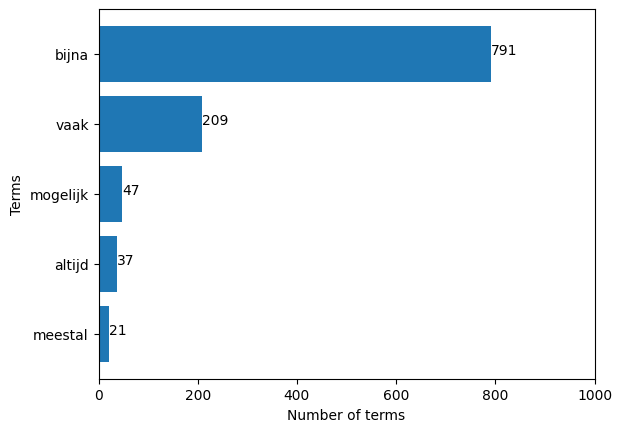

In [20]:
df_sorted = df22.sort_values("freq", ascending= False)

df_sorted = df_sorted.sort_values(by = "freq", ascending=True)
df_sorted5 = df_sorted.tail(5)
def addlabels(df_sorted5):
    for i in range(len(df_sorted5)):
        plt.text(df_sorted5.iloc[i]["freq"] + 0.1,i, str(df_sorted5.iloc[i]["freq"]), fontsize = 10)
plt.barh(df_sorted5["words"] ,df_sorted5["freq"])
addlabels(df_sorted5)
plt.xlabel("Number of terms")
plt.ylabel("Terms")
plt.yticks(fontsize = 10)
plt.xlim(0,1000)
plt.show()

2023

In [21]:

doc_u_counts = Counter()
filenames = []
total_u_counts = 0
for file in os.listdir("2023_a"):
    file_path = os.path.join("2023_a", file)
    doc = tokenize(file_path)
    terms = find_uncertainty_terms(doc)
    if terms:
        total_u_counts += 1
        doc_u_counts.update(terms)
        filenames.append(file)


y = list(doc_u_counts.values())
x = list(doc_u_counts.keys())
df23 = pd.DataFrame(dict(words = doc_u_counts.keys(), freq = doc_u_counts.values()))


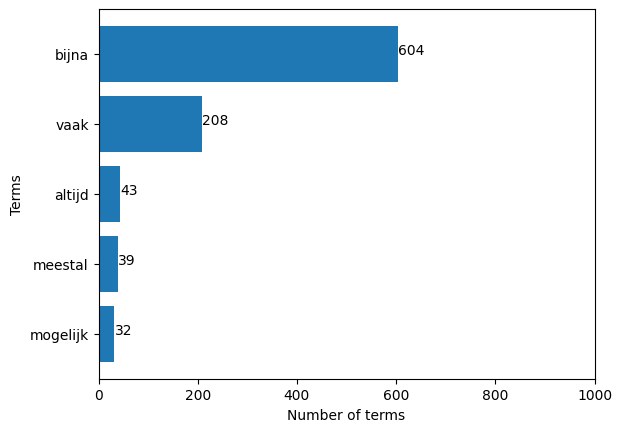

In [22]:
df_sorted = df23.sort_values("freq", ascending= False)

df_sorted = df_sorted.sort_values(by = "freq", ascending=True)
df_sorted5 = df_sorted.tail(5)
def addlabels(df_sorted5):
    for i in range(len(df_sorted5)):
        plt.text(df_sorted5.iloc[i]["freq"] + 0.1,i, str(df_sorted5.iloc[i]["freq"]), fontsize = 10)
plt.barh(df_sorted5["words"] ,df_sorted5["freq"])
addlabels(df_sorted5)
plt.xlabel("Number of terms")
plt.ylabel("Terms")
plt.yticks(fontsize = 10)
plt.xlim(0,1000)
plt.show()

2024

In [23]:

doc_u_counts = Counter()
filenames = []
total_u_counts = 0
for file in os.listdir("2024_a"):
    file_path = os.path.join("2024_a", file)
    doc = tokenize(file_path)
    terms = find_uncertainty_terms(doc)
    if terms:
        total_u_counts += 1
        doc_u_counts.update(terms)
        filenames.append(file)


y = list(doc_u_counts.values())
x = list(doc_u_counts.keys())
df24 = pd.DataFrame(dict(words = doc_u_counts.keys(), freq = doc_u_counts.values()))


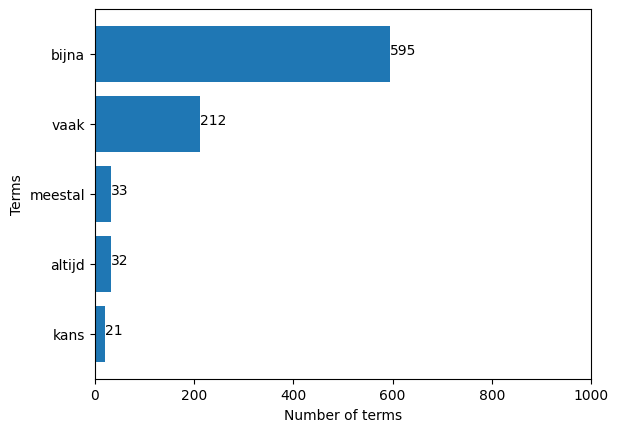

In [24]:
df_sorted = df24.sort_values("freq", ascending= False)

df_sorted = df_sorted.sort_values(by = "freq", ascending=True)
df_sorted5 = df_sorted.tail(5)
def addlabels(df_sorted5):
    for i in range(len(df_sorted5)):
        plt.text(df_sorted5.iloc[i]["freq"] + 0.1,i, str(df_sorted5.iloc[i]["freq"]), fontsize = 10)
plt.barh(df_sorted5["words"] ,df_sorted5["freq"])
addlabels(df_sorted5)
plt.xlabel("Number of terms")
plt.ylabel("Terms")
plt.yticks(fontsize = 10)
plt.xlim(0,1000)
plt.show()

5. Plots the relationship between mean and year with two Linear models

  0% (0 of 10) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 70% (7 of 10) |#################        | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (10 of 10) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


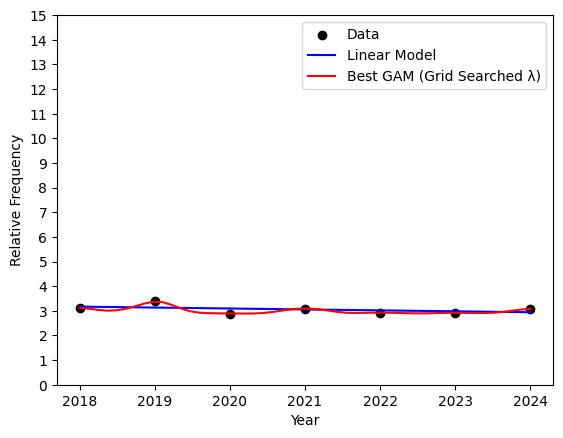

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pygam 
from pygam import s, LinearGAM,f
import numpy as np
import gam
from sklearn.linear_model import LinearRegression


d = {"year" : [2018,2019,2020,2021,2022,2023,2024], "no of docs":[df_2018.shape[0],df_2019.shape[0], df_2020.shape[0], df_2021.shape[0], df_2022.shape[0], df_2023.shape[0], df_2024.shape[0]], "uncertainty count":[df_2018["Uncertainty Counts"].sum(), df_2019["Uncertainty Counts"].sum(), df_2020["Uncertainty Counts"].sum(), df_2021["Uncertainty Counts"].sum(), df_2022["Uncertainty Counts"].sum(), df_2023["Uncertainty Counts"].sum(), df_2024["Uncertainty Counts"].sum()]}
df = pd.DataFrame(data = d)

df["year"] = pd.to_numeric(df["year"])
df["uncertainty count"] = pd.to_numeric(df["uncertainty count"])
df["Relative_Freq"] = df["uncertainty count"]/df["no of docs"]

#reshape values 
X = df["year"].values
X = X.reshape(-1,1)
y = df["Relative_Freq"].values

## plot points
plt.scatter(df["year"],df["Relative_Freq"], label = "Data", color = "Black")
plt.ylim(0,15)
plt.yticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15])

# linear model 
linear_reg = LinearRegression()
linear_reg.fit(X,y)
y_pred_lin = linear_reg.predict(X)
plt.plot(df["year"], y_pred_lin, color = "blue", label = "Linear Model")

gam = LinearGAM(s(0))
# grid search for lambda 
lam = np.logspace(-2,2,10)
gam_grid = gam.gridsearch(X,y, lam = lam)
X_pred = np.linspace(X.min(), X.max(), 50).reshape(-1,1)
y_pred_gam = gam_grid.predict(X_pred)
plt.plot(X_pred, y_pred_gam, color = "red", label = "Best GAM (Grid Searched λ)")

plt.xlabel("Year")
plt.ylabel("Relative Frequency")
plt.legend(loc = "upper right")

